# 🔬 Visualization Mini-Lab: Trends and Outliers

Now it’s time to put your skills to the test!
In this mini-lab, you’ll explore a real dataset, create visualizations, and identify **trends and outliers**.

We’ll use the famous **Penguins dataset** (thanks to Seaborn).

In [1]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

try:
    penguins = sns.load_dataset("penguins")
except Exception:
    penguins = pd.DataFrame({
        "species": ["Adelie", "Adelie", "Chinstrap", "Chinstrap", "Gentoo", "Gentoo"],
        "island": ["Torgersen", "Dream", "Dream", "Dream", "Biscoe", "Biscoe"],
        "bill_length_mm": [39.1, 40.3, 48.7, 50.2, 46.1, 49.8],
        "bill_depth_mm": [18.7, 18.0, 17.4, 18.1, 13.2, 15.0],
        "flipper_length_mm": [181, 195, 195, 202, 211, 230],
        "body_mass_g": [3750, 3250, 3800, 4050, 4500, 5700],
        "sex": ["Male", "Female", "Female", "Male", "Female", "Male"],
    })

penguins.head()


,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,Male
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,Female
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,Female
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,Female


## 1. Explore Distributions

First, let’s look at the distribution of **body mass**.

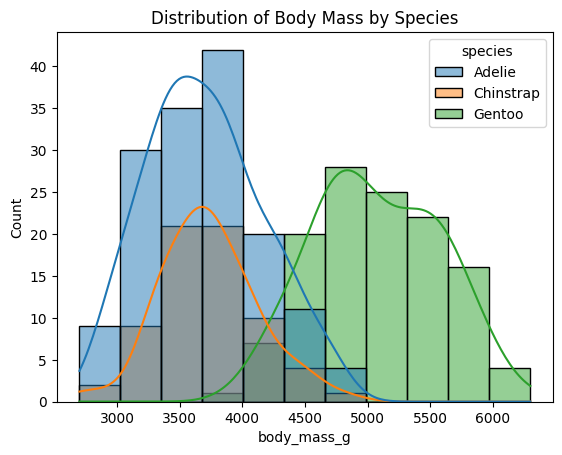

In [2]:
sns.histplot(data=penguins, x="body_mass_g", kde=True, hue="species")
plt.title("Distribution of Body Mass by Species")
plt.show()

👉 **Task:** Do some species have higher average body mass than others?

In [3]:
# Task 1 answer
penguins.groupby("species")["body_mass_g"].mean().sort_values(ascending=False)


species
Gentoo       5076.016260
Chinstrap    3733.088235
Adelie       3700.662252
Name: body_mass_g, dtype: float64

Gentoo penguins have the highest average body mass in this dataset, followed by Chinstrap and Adelie.

## 2. Relationships Between Variables

Scatterplots help us see trends between two quantitative variables.

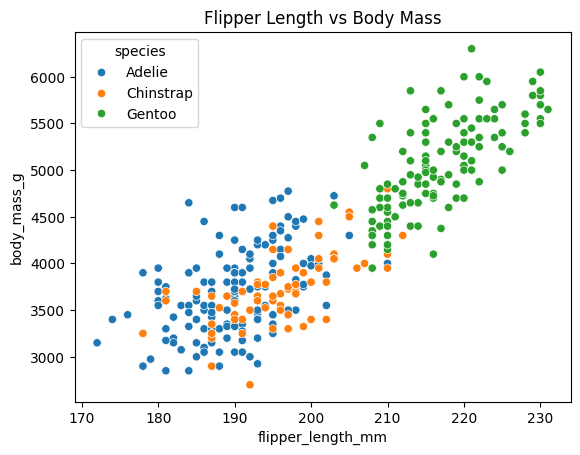

In [4]:
sns.scatterplot(data=penguins, x="flipper_length_mm", y="body_mass_g", hue="species")
plt.title("Flipper Length vs Body Mass")
plt.show()

👉 **Task:** Which species tends to have longer flippers AND higher body mass?

In [5]:
# Task 2 answer
penguins.groupby("species")[["flipper_length_mm", "body_mass_g"]].mean().sort_values("body_mass_g", ascending=False)


,flipper_length_mm,body_mass_g
species,,
Gentoo,217.186992,5076.016260
Chinstrap,195.823529,3733.088235
Adelie,189.953642,3700.662252


Gentoo tends to have both longer flippers and higher body mass.

## 3. Box Plots for Outliers

Box plots are great for spotting outliers.

C:\Users\demii\AppData\Local\Temp\ipykernel_8652\722458408.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=penguins, x="species", y="bill_length_mm", palette="Set2")


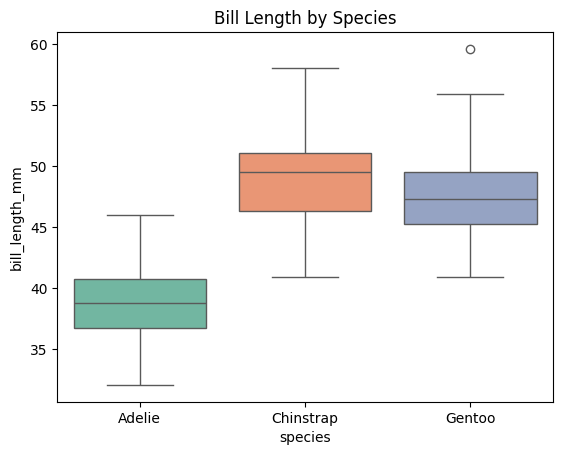

In [6]:
sns.boxplot(data=penguins, x="species", y="bill_length_mm", palette="Set2")
plt.title("Bill Length by Species")
plt.show()

👉 **Task:** Can you spot any outliers in the bill length data?

In [7]:
# Task 3 answer: identify possible bill-length outliers by IQR within each species
outliers = []
for species, group in penguins.dropna(subset=["bill_length_mm"]).groupby("species"):
    q1 = group["bill_length_mm"].quantile(0.25)
    q3 = group["bill_length_mm"].quantile(0.75)
    iqr = q3 - q1
    low = q1 - 1.5 * iqr
    high = q3 + 1.5 * iqr
    outliers.append(group[(group["bill_length_mm"] < low) | (group["bill_length_mm"] > high)])

pd.concat(outliers) if outliers else pd.DataFrame()


,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
253,Gentoo,Biscoe,59.6,17.0,230.0,6050.0,Male


The box plot can show individual points beyond the whiskers; those are possible bill-length outliers worth inspecting.

## 4. Correlation Heatmap

Correlation heatmaps let us see overall variable relationships.

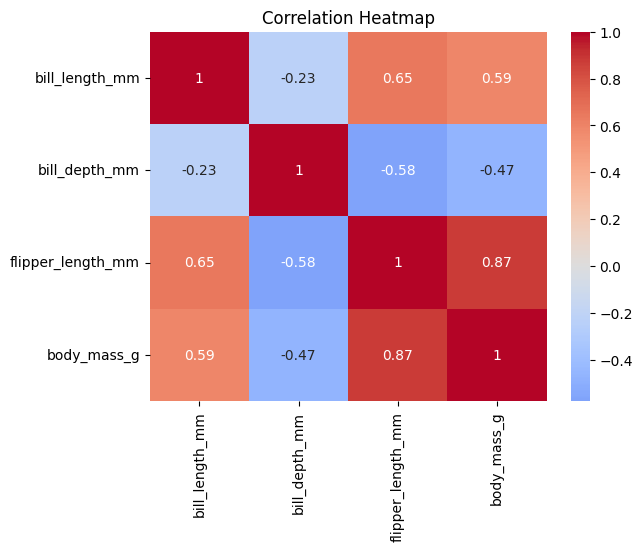

In [8]:
corr = penguins.dropna().corr(numeric_only=True)
sns.heatmap(corr, annot=True, cmap="coolwarm", center=0)
plt.title("Correlation Heatmap")
plt.show()

👉 **Task:** Which variables appear to be strongly correlated?

In [9]:
# Task 4 answer
corr = penguins.dropna().corr(numeric_only=True)
corr.abs().unstack().sort_values(ascending=False).drop_duplicates().head(10)


bill_length_mm     bill_length_mm       1.000000
flipper_length_mm  body_mass_g          0.872979
bill_length_mm     flipper_length_mm    0.653096
                   body_mass_g          0.589451
flipper_length_mm  bill_depth_mm        0.577792
bill_depth_mm      body_mass_g          0.472016
                   bill_length_mm       0.228626
dtype: float64

Body mass and flipper length usually show one of the strongest positive correlations. Bill length and flipper length also tend to have a noticeable relationship.

## 5. Your Turn

- Try a different dataset (e.g., `tips`, `iris`).
- Create **at least 2 plots** that reveal a trend.
- Create **1 plot** that highlights possible outliers.
- Write a short summary of your findings.

> Remember: The goal is to **use visualizations to tell a story about the data.**

In [10]:
# Your Turn solution using the tips dataset
tips = sns.load_dataset("tips")
tips.head()


,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4


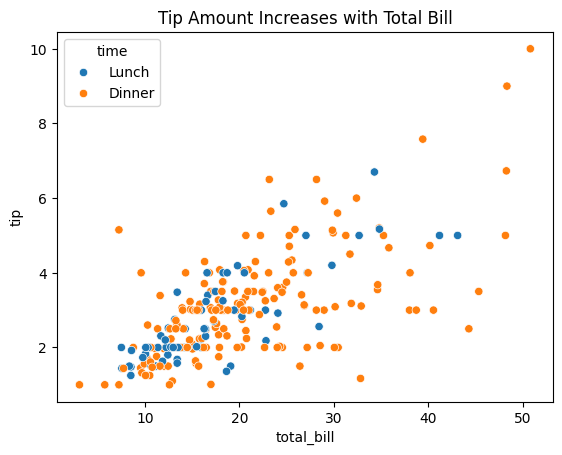

In [11]:
# Plot 1: trend between total bill and tip
sns.scatterplot(data=tips, x="total_bill", y="tip", hue="time")
plt.title("Tip Amount Increases with Total Bill")
plt.show()


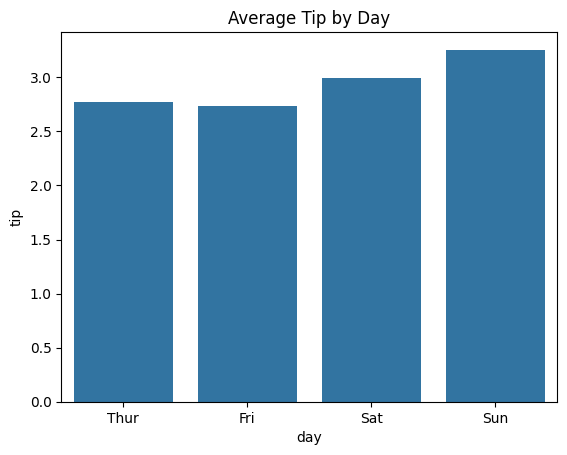

In [12]:
# Plot 2: average tip by day
sns.barplot(data=tips, x="day", y="tip", estimator="mean", errorbar=None)
plt.title("Average Tip by Day")
plt.show()


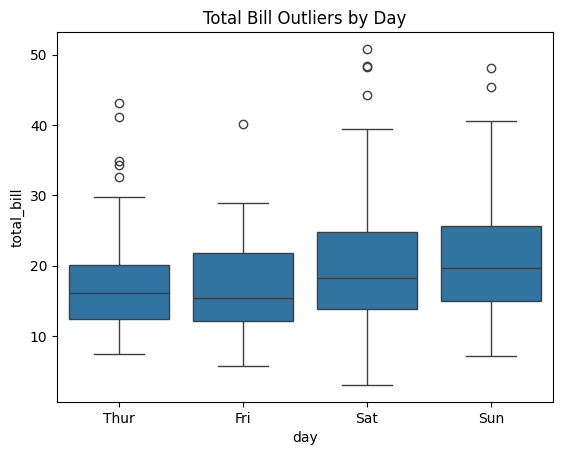

In [13]:
# Outlier plot: total bill by day
sns.boxplot(data=tips, x="day", y="total_bill")
plt.title("Total Bill Outliers by Day")
plt.show()


In the tips dataset, larger total bills generally correspond to larger tips. The box plot also shows that some days have unusually large bills compared with the middle of the distribution.

---
✅ Congratulations! You’ve completed the visualization mini-lab and Week 07.

Next module → Working with larger datasets and diving deeper into analysis.